In [2]:
import numpy as np ##数据处理的package
import matplotlib.pyplot as plt ##作图的包

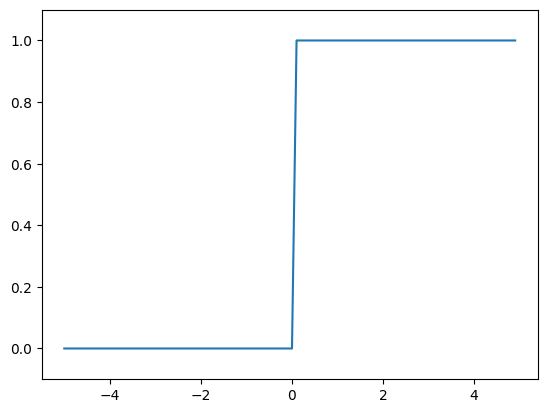

In [2]:
def step_function_np2(x):
    return np.array(x > 0, dtype=np.int_)

x = np.arange(-5, 5, 0.1)
y = step_function_np2(x)
plt.plot(x, y)##画图
plt.ylim(-0.1, 1.1)###指定y轴
plt.show()

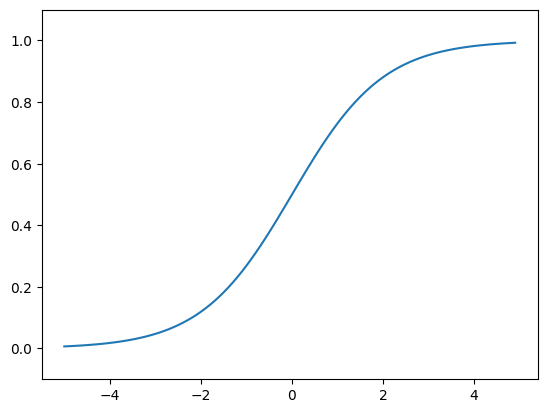

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

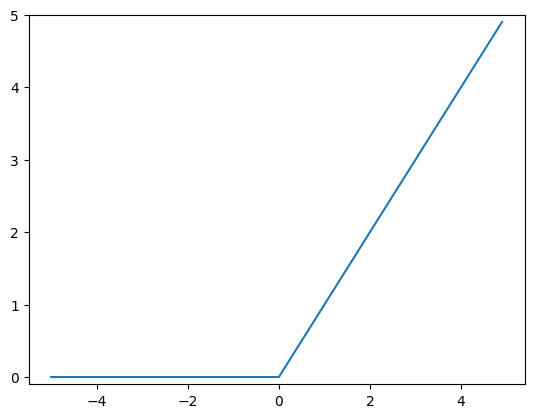

In [3]:
def relu(x):
    return np.maximum(0, x)
x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-0.1, 5)
plt.show()

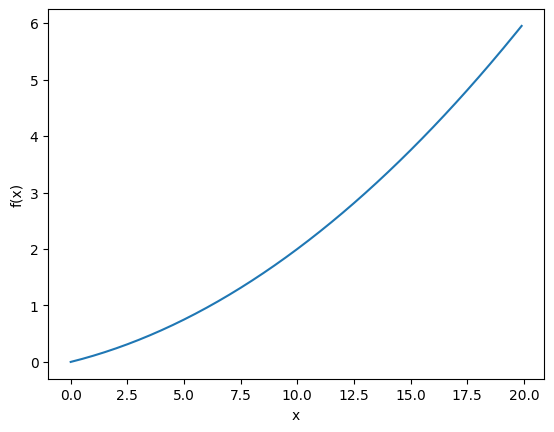

In [1]:
def function_1(x):
    return 0.01*x**2 + 0.1*x
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0, 20.0, 0.1)
y = function_1(x)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x, y)
plt.show()

time: 0
train accuracy: 0.09736666666666667 test accuracy: 0.0982
time: 1
time: 2
time: 3
time: 4
time: 5
time: 6
time: 7
time: 8
time: 9
time: 10
time: 11
time: 12
time: 13
time: 14
time: 15
time: 16
time: 17
time: 18
time: 19
time: 20
time: 21
time: 22
time: 23
time: 24
time: 25
time: 26
time: 27
time: 28
time: 29
time: 30
time: 31
time: 32
time: 33
time: 34
time: 35
time: 36
time: 37
time: 38
time: 39
time: 40
time: 41
time: 42
time: 43
time: 44
time: 45
time: 46
time: 47
time: 48
time: 49
time: 50
time: 51
time: 52
time: 53
time: 54
time: 55
time: 56
time: 57
time: 58
time: 59
time: 60
time: 61
time: 62
time: 63
time: 64
time: 65
time: 66
time: 67
time: 68
time: 69
time: 70
time: 71
time: 72
time: 73
time: 74
time: 75
time: 76
time: 77
time: 78
time: 79
time: 80
time: 81
time: 82
time: 83
time: 84
time: 85
time: 86
time: 87
time: 88
time: 89
time: 90
time: 91
time: 92
time: 93
time: 94
time: 95
time: 96
time: 97
time: 98
time: 99
time: 100
time: 101
time: 102
time: 103
time: 104
ti

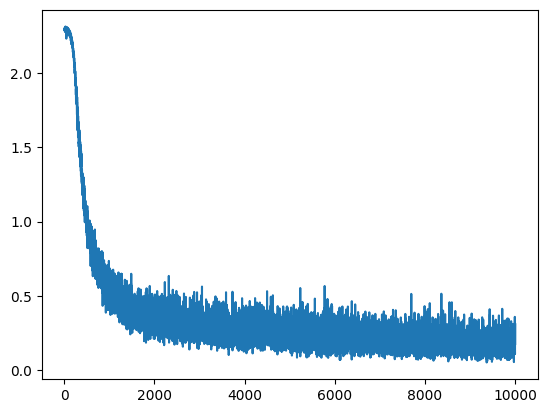

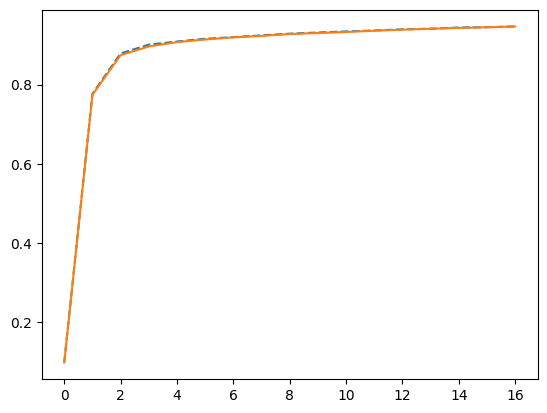

In [1]:

####mini-batch
import numpy as np
from DeepLearning_from_Scratch.code.dataset.mnist import load_mnist
from DeepLearning_from_Scratch.code.ch04.two_layer_net import TwoLayerNet
from matplotlib import pyplot as plt

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

###chao can shu rengongshhezhi de canshu

iters_num = 10000  ####训练次数
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_lost_list = []
train_acc_list = []
test_acc_list = []
iter_per_epoch = max(train_size / batch_size, 1)

network = TwoLayerNet(784, 50, 10)

for i in range(iters_num):
    ###mini-batch
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    ###计算梯度
    grad = network.gradient(x_batch, t_batch)###使用高速版代码，跑的太慢了。提速达千倍
    ### grad = network.gradient() fast speed
    ###更新参数
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    ### 记录学习过程
    print("time:",i)
    loss = network.loss(x_batch, t_batch)
    train_lost_list.append(loss)
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train accuracy:", train_acc, "test accuracy:", test_acc)


X_axis = range(iters_num)
plt.plot(X_axis, train_lost_list)
plt.show()
X_axis = range(np.array(train_acc_list).size)
plt.plot(X_axis, test_acc_list, linestyle='--')
plt.plot(X_axis, train_acc_list)
plt.show()
plt.savefig()



In [6]:
import os
file_path = "D://Deeplearning//images"

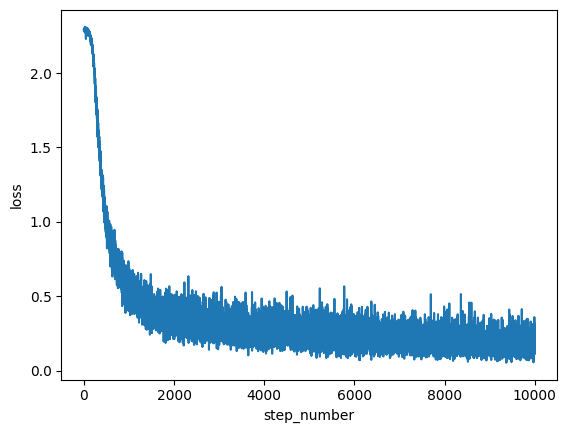

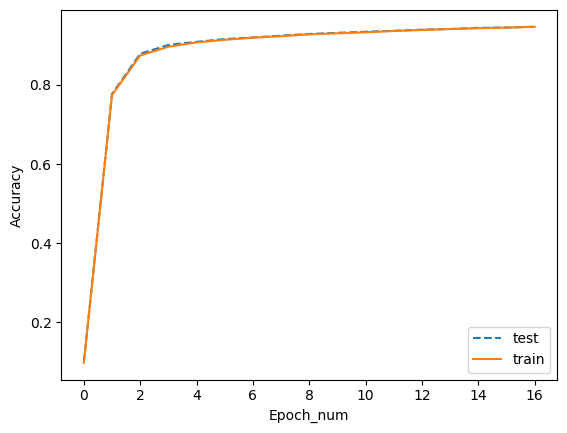

In [7]:
X_axis = range(iters_num)
plt.plot(X_axis, train_lost_list)
plt.xlabel('step_number')
plt.ylabel('loss')
plt.savefig(file_path + "loss.png", dpi=300)
plt.show()

X_axis = range(np.array(train_acc_list).size)
plt.plot(X_axis, test_acc_list, linestyle='--')
plt.plot(X_axis, train_acc_list)
plt.xlabel("Epoch_num")
plt.ylabel("Accuracy")
plt.legend(["test", "train"])
plt.savefig(file_path + "acc_epoch.png", dpi=300)
plt.show()

